### Prompt Chaining

In [2]:
from langchain_groq import ChatGroq
from dotenv import load_dotenv
load_dotenv()

import os
os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")

llm= ChatGroq(model="gemma2-9b-it")

result= llm.invoke("Hello")
result

AIMessage(content='Hello! 👋\n\nHow can I help you today?\n', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 14, 'prompt_tokens': 11, 'total_tokens': 25, 'completion_time': 0.025454545, 'prompt_time': 0.002038021, 'queue_time': 0.258422617, 'total_time': 0.027492566}, 'model_name': 'gemma2-9b-it', 'system_fingerprint': 'fp_10c08bf97d', 'finish_reason': 'stop', 'logprobs': None}, id='run--456a4f5d-4e4e-47d7-ae7e-d7ef6d0add3c-0', usage_metadata={'input_tokens': 11, 'output_tokens': 14, 'total_tokens': 25})

In [3]:
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from IPython.display import Image, display

## Graph State
class State(TypedDict):
    topic: str
    story: str
    improved_story:str
    final_story:str

##Nodes

def generate_story(state: State) :
    msg = llm.invoke(f"Write a story about {state['topic']}")
    return {"story":msg.content}

def check_conflict(state:State):
    if "?" in state["story"] or "!" in state ["story"]:
        return "fail"
    return "Pass"


def improved_story(state:State):
    msg= llm.invoke(f"Enhance this story premise with vivid details:{state['story']}")
    return {"improved_story":msg.content}

def polish_story(state:State):
    msg= llm.invoke(f"Add an unexpected twist to this story premise:{state['improved_story']}")
    return {"final_story":msg.content}




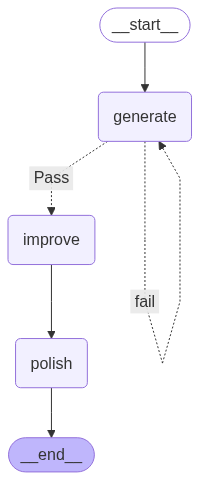

In [5]:
### build the graph

graph= StateGraph(State)
graph.add_node("generate", generate_story)
graph.add_node("improve", improved_story)
graph.add_node("polish", polish_story)

## define the edges
graph.add_edge(START, "generate")
graph.add_conditional_edges("generate",check_conflict,{"Pass":"improve", "fail":"generate"})
graph.add_edge("improve", "polish")
graph.add_edge("polish", END)

compiled_graph= graph.compile()
graph_image= compiled_graph.get_graph().draw_mermaid_png()
display(Image(graph_image))

In [8]:
### run the graph

state={"topic":"DC superheroes"}
result= compiled_graph.invoke(state)
result

{'topic': 'DC superheroes',
 'story': 'Rain lashed against the crumbling facade of Wayne Tower, mirroring the storm brewing inside Batman. He stood amidst the wreckage of the Batcave, the chill of failure clinging to him like a shroud. The Joker had won again, his chaotic laughter echoing in the silence, a cruel reminder of the gaping hole in Gotham\'s defenses.\n\n"It\'s always the same, Bruce," a calm voice spoke from behind him.\n\nBatman turned to see Wonder Woman, her brow furrowed with concern. She held a canteen, offering it to him. "You need to rest."\n\nHe shook his head, the metallic tang of blood in his mouth. "There\'s no time, Diana. He\'s already planning his next move."\n\n"He\'s a master of chaos, Bruce," she said, her voice firm. "But even he needs time to regroup. You need to let your anger fade, to strategize. Don\'t let him consume you."\n\nBatman hesitated, then accepted the canteen. He needed her wisdom, her unwavering belief in him. He needed to remember that he 